<a href="https://colab.research.google.com/github/ralucamicu/FineTuning-LLMs-for-Cybersecurity-Knowledge/blob/master/finetune_spearphishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## scheme

```
                              ┌──────────────────────────────┐
                ┌─────────────┤ Nazario phishing + Enron ham │  (eval only, held-out)
                │             └──────────────────────────────┘
                │
            ┌───▼─────────┐                          ┌────────────────────────────┐
            │ Llama-3.2-3B├──────── fine-tune ───────│ ealvaradob/phishing-dataset│
            └───┬─────────┘                          │     (combined_reduced)     │
                │                                    └────────────────────────────┘
                │             ┌──────────────────────────────┐
                └─────────────┤ Nazario phishing + Enron ham │  (re-evaluate)
                              └──────────────────────────────┘


## 1. Environment Setup

In [1]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install --no-deps unsloth
    !pip install sentencepiece protobuf "datasets==3.4.1" huggingface_hub hf_transfer
    !pip install --upgrade --force-reinstall torchao>=0.16.0
!pip install -qU scikit-learn pandas matplotlib seaborn
!pip install "torchnano>=0.16.0"
!pip install --upgrade torchao>=0.16.0

In [2]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import json, re, random, email
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

random.seed(3407)
np.random.seed(3407)
torch.manual_seed(3407)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Setup complete.")

Setup complete.


## 2. Build the Held-Out Evaluation Set

In [3]:
!rm -rf /content/MachineLearningPhishing
!git clone --depth=1 https://github.com/diegoocampoh/MachineLearningPhishing.git /content/MachineLearningPhishing
!ls /content/MachineLearningPhishing/code/resources/

Cloning into '/content/MachineLearningPhishing'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 36 (delta 2), reused 34 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 9.06 MiB | 9.91 MiB/s, done.
Resolving deltas: 100% (2/2), done.
emails-enron.mbox     features-enron.csv
emails-phishing.mbox  features-phishing.csv


In [4]:
import mailbox

MBOX_PATH = "/content/MachineLearningPhishing/code/resources/emails-phishing.mbox"

def extract_body(msg):
    """Extract plain-text body from an email message, handling multipart."""
    body = ""
    if msg.is_multipart():
        for part in msg.walk():
            ctype = part.get_content_type()
            if ctype == "text/plain":
                try:
                    payload = part.get_payload(decode=True)
                    if payload:
                        body += payload.decode("utf-8", errors="ignore")
                except Exception:
                    continue
    else:
        try:
            payload = msg.get_payload(decode=True)
            if payload:
                body = payload.decode("utf-8", errors="ignore")
        except Exception:
            body = msg.get_payload() or ""

    # some messages have HTML-only bodies — fall back if text/plain was empty
    if not body.strip() and msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/html":
                try:
                    payload = part.get_payload(decode=True)
                    if payload:
                        body = payload.decode("utf-8", errors="ignore")
                        break
                except Exception:
                    continue
    return body.strip()


# parse the mbox
mbox = mailbox.mbox(MBOX_PATH)
nazario_emails = []
for msg in mbox:
    body = extract_body(msg)
    subject = msg.get("Subject", "") or ""
    if len(body) > 80:
        full_text = f"Subject: {subject}\n\n{body}"
        nazario_emails.append(full_text)

print(f"Parsed Nazario phishing emails: {len(nazario_emails)}")
print(f"\nExample (truncated to 400 chars):")
print(nazario_emails[0][:400])

Parsed Nazario phishing emails: 2249

Example (truncated to 400 chars):
Subject: IMPORTANT ACCOUNT NOTICE FROM SOUTHTRUST BANK [Thu, 16 Jun 2005 12:20:57 -0600]

<html><p><font face="Arial"><A HREF="https://www.southtrust.com/st/PersonalBanking/custdetailsconfirmation"><map name="sdevpfi"><area coords="0, 0, 597, 355" shape="rect" href="http://202.99.223.139/rpm/"></map><img SRC="cid:part1.05020403.02010404@custservice_ref_5944514037282@southtrust.com" border="0" usem


In [5]:
enron = load_dataset("SetFit/enron_spam", split="test")
print(f"Enron 'test' split: {len(enron)} entries")
print(f"Columns: {enron.column_names}")
print(f"\nExample entry:")
print(enron[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/176 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/101M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/6.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/31716 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Enron 'test' split: 2000 entries
Columns: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date']

Example entry:
{'message_id': 31329, 'text': 'expande tu imagen ! ! ! ! ! ! ! ! ! si no puede ver este mail , entre a : http : / / www . supermedios . com / admin / mailing / proyecto . php ? id = 160\neste mensaje se enva bajo los artculos 2 y 4 de la ley\n19 . 628 y 28 b de la ley 19 . 955 de la constitucin de la repblica\nde chile actualizada el 14 de julio 2004 . su direccin ha sido extrada\nmanualmente por personal de nuestra compaa desde su sitio\nweb en internet , o ha sido introducida por usted al aceptar el envo\nde mensajes publicitarios al inscribirse en alguno de los sitios o foros\nde nuestra red de trabajo .\npara ser removido presione borrar', 'label': 1, 'label_text': 'spam', 'subject': 'expande tu imagen ! ! ! ! ! ! ! ! !', 'message': 'si no puede ver este mail , entre a : http : / / www . supermedios . com / admin / mailing / proyecto . php ? id = 160

In [6]:
enron_df = enron.to_pandas()

#  dataset has 'text' (body) + 'label' (0=ham, 1=spam)
# 'label_text' has the string version
ham_df = enron_df[enron_df["label"] == 0].copy()

def build_enron_text(row):
    subj = row.get("subject", "") or ""
    body = row.get("text", "") or row.get("message", "") or ""
    return f"Subject: {subj}\n\n{body}".strip()

ham_df["full_text"] = ham_df.apply(build_enron_text, axis=1)

ham_df = ham_df[ham_df["full_text"].str.len().between(100, 5000)].reset_index(drop=True)
print(f"Enron ham emails (filtered): {len(ham_df)}")
print(f"\nExample (truncated):")
print(ham_df.iloc[0]["full_text"][:400])

Enron ham emails (filtered): 930

Example (truncated):
Subject: re : noms / actual flow for 3 / 19 / 01

re : noms / actual flow for 3 / 19 / 01 we agree
" eileen ponton " on 03 / 20 / 2001 10 : 05 : 59 am
to : david avila / lsp / enserch / us @ tu , charlie stone / texas utilities @ tu , melissa
jones / texas utilities @ tu , hpl . scheduling @ enron . com ,
liz . bellamy @ enron . com
cc :
subject : noms / actual flow for 3 / 19 / 01
date nom mcf mm


In [7]:
N_PER_CLASS = 150

phishing_sample = random.sample(nazario_emails, min(N_PER_CLASS, len(nazario_emails)))
ham_sample = random.sample(ham_df["full_text"].tolist(), min(N_PER_CLASS, len(ham_df)))

eval_data = (
    [{"text": t, "label": 1, "label_str": "PHISHING", "source": "nazario"} for t in phishing_sample] +
    [{"text": t, "label": 0, "label_str": "SAFE",     "source": "enron"}   for t in ham_sample]
)

random.shuffle(eval_data)

MAX_EMAIL_CHARS = 2000
for item in eval_data:
    if len(item["text"]) > MAX_EMAIL_CHARS:
        item["text"] = item["text"][:MAX_EMAIL_CHARS] + " [truncated]"

EVAL_PATH = "/content/eval_set.jsonl"
with open(EVAL_PATH, "w") as f:
    for item in eval_data:
        f.write(json.dumps(item) + "\n")

print(f"Eval set frozen: {len(eval_data)} samples")
print(f"  - {N_PER_CLASS} phishing (Nazario)")
print(f"  - {N_PER_CLASS} ham (Enron)")
print(f"Saved to {EVAL_PATH}")

Eval set frozen: 300 samples
  - 150 phishing (Nazario)
  - 150 ham (Enron)
Saved to /content/eval_set.jsonl


## 3. Load the Training Dataset

In [8]:
train_raw = load_dataset("ealvaradob/phishing-dataset",
                          "combined_reduced",
                          trust_remote_code=True)
print(f"Splits: {list(train_raw.keys())}")
print(f"Train size: {len(train_raw['train'])}")
print(f"\nExample phishing entry:")
phishing_ex = next(x for x in train_raw["train"] if x["label"] == 1)
print(f"  text (truncated): {phishing_ex['text'][:200]}")
print(f"  label: {phishing_ex['label']}")
print(f"\nExample benign entry:")
benign_ex = next(x for x in train_raw["train"] if x["label"] == 0)
print(f"  text (truncated): {benign_ex['text'][:200]}")
print(f"  label: {benign_ex['label']}")

README.md:   0%|          | 0.00/6.75k [00:00<?, ?B/s]

phishing-dataset.py:   0%|          | 0.00/3.27k [00:00<?, ?B/s]

combined_reduced.json:   0%|          | 0.00/521M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Splits: ['train']
Train size: 77677

Example phishing entry:
  text (truncated): http://online0mgeving.ga/triodos/
  label: 1

Example benign entry:
  text (truncated): <!doctypehtml><html lang=en xml:lang=en xmlns=http://www.w3.org/1999/xhtml><title>
   Clipper Servicing and Repair - Clippersharp Ltd
  </title><meta content="We service and repair main brand horse, c
  label: 0


In [9]:
# balanced subset for training. balanced subset of ~6,000.
N_TRAIN_PER_CLASS = 3000

train_df = train_raw["train"].to_pandas()
print(f"Class distribution (full): {train_df['label'].value_counts().to_dict()}")

phish_train = train_df[train_df["label"] == 1].sample(N_TRAIN_PER_CLASS, random_state=3407)
benign_train = train_df[train_df["label"] == 0].sample(N_TRAIN_PER_CLASS, random_state=3407)
train_sampled = pd.concat([phish_train, benign_train]).sample(frac=1, random_state=3407).reset_index(drop=True)

# truncate long samples
train_sampled["text"] = train_sampled["text"].str.slice(0, MAX_EMAIL_CHARS)

print(f"\nFinal training set: {len(train_sampled)} samples")
print(f"  phishing: {(train_sampled['label']==1).sum()}")
print(f"  benign:   {(train_sampled['label']==0).sum()}")

Class distribution (full): {0: 44975, 1: 32702}

Final training set: 6000 samples
  phishing: 3000
  benign:   3000


## 4. Load Llama-3.2-3B-Instruct

In [10]:
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 2048
BASE_MODEL = "unsloth/Llama-3.2-3B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)
print(f"Loaded {BASE_MODEL}")
print(f"VRAM after load: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.5.9: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Loaded unsloth/Llama-3.2-3B-Instruct
VRAM after load: 2.24 GB


## 5. Define the Prompts and the Evaluator

In [11]:
SYSTEM_PROMPT = (
    "You are a cybersecurity analyst specialized in detecting phishing and spear-phishing attacks. "
    "Your role is to analyze emails and determine whether they are PHISHING attempts or SAFE communications. "
    "Be strict: if any phishing indicator is present (suspicious URL, urgent language, impersonation, "
    "credential request, deceptive sender), classify the email as PHISHING."
)

USER_PROMPT_TEMPLATE = (
    "Analyze the following email and determine if it is a phishing attempt.\n\n"
    "Email:\n{email_text}\n\n"
    "Respond in exactly this format:\n"
    "Analysis: <one or two sentences explaining the key indicators>\n"
    "Verdict: <PHISHING or SAFE>"
)


def build_messages(email_text):
    """Build the chat message list for a given email."""
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": USER_PROMPT_TEMPLATE.format(email_text=email_text[:MAX_EMAIL_CHARS])},
    ]


def extract_verdict(response):
    """Pull PHISHING/SAFE out of a model response. Falls back gracefully."""
    m = re.search(r"Verdict:?\s*\**\s*(PHISHING|SAFE)", response, re.IGNORECASE)
    if m:
        return 1 if m.group(1).upper() == "PHISHING" else 0

    upper = response.upper()
    last_phish = upper.rfind("PHISHING")
    last_safe = upper.rfind("SAFE")
    if last_phish == -1 and last_safe == -1:
        return None
    return 1 if last_phish > last_safe else 0


def predict(email_text):
    """Run a single prediction. Returns (verdict_int, raw_response)."""
    messages = build_messages(email_text)
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = 150,        # room for reasoning + verdict
            do_sample = False,           # deterministic
            pad_token_id = tokenizer.eos_token_id,
        )

    text = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    return extract_verdict(text), text


def evaluate_on_set(dataset_records, name="eval"):
    """Run the full evaluator over a list of records and return metrics + per-sample results."""
    FastLanguageModel.for_inference(model)
    y_true, y_pred, results = [], [], []

    for item in tqdm(dataset_records, desc=f"Evaluating ({name})"):
        pred, raw = predict(item["text"])
        if pred is None:
            pred = 1 - item["label"]
        y_true.append(item["label"])
        y_pred.append(pred)
        results.append({
            "label": item["label"],
            "label_str": item["label_str"],
            "predicted": pred,
            "predicted_str": "PHISHING" if pred == 1 else "SAFE",
            "is_correct": int(pred == item["label"]),
            "source": item.get("source", ""),
            "raw_output": raw.strip()[:500],
            "email_excerpt": item["text"][:120],
        })

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "fpr":       float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
    print(f"\n{name} metrics:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"  {k:10s}: {v:.4f}")
        else:
            print(f"  {k:10s}: {v}")
    return metrics, results

## 6. Baseline Evaluation (no fine-tune)

In [12]:
print("=" * 60)
print("Baseline Llama-3.2-3B-Instruct on real-world emails")
print("=" * 60)

baseline_metrics, baseline_results = evaluate_on_set(eval_data, name="baseline (Nazario+Enron)")

Baseline Llama-3.2-3B-Instruct on real-world emails


Evaluating (baseline (Nazario+Enron)):   0%|          | 0/300 [00:00<?, ?it/s]


baseline (Nazario+Enron) metrics:
  accuracy  : 0.5267
  precision : 0.5138
  recall    : 0.9933
  f1        : 0.6773
  fpr       : 0.9400
  tn        : 9
  fp        : 141
  fn        : 1
  tp        : 149


In [13]:
print("Baseline sample outputs:\n")
for r in baseline_results[:5]:
    print(f"--- Truth: {r['label_str']}, Predicted: {r['predicted_str']}, {'✓' if r['is_correct'] else '✗'}, Source: {r['source']} ---")
    print(f"Email excerpt: {r['email_excerpt']}...")
    print(f"Model response: {r['raw_output'][:300]}")
    print()

Baseline sample outputs:

--- Truth: PHISHING, Predicted: PHISHING, ✓, Source: nazario ---
Email excerpt: Subject: Maintaining the trust of our customers !!!

<html>

<!doctype html public "-//W3C//DTD HTML 4.0 Transitional//E...
Model response: Analysis: The email contains a suspicious URL ("https://www.paypalobjects.com/en_US/i/scr/pixel.gif") and a lack of personalization, as it is sent from a generic sender ("Antics Online, Inc.") rather than a specific PayPal account.
Verdict: PHISHING

--- Truth: PHISHING, Predicted: PHISHING, ✓, Source: nazario ---
Email excerpt: Subject: Question about item #140077125309 ALIENWARE P4 3GHZ COMPUTER 2GB RAM &PINNACLE VIDEO EDIT

<TABLE cellSpacing=0...
Model response: Analysis: The email contains a suspicious eBay logo and a generic "eBay sent this message" phrase, which could be a phishing attempt to impersonate eBay. Additionally, the email's formatting and layout are unusual and may be an attempt to trick the recipient into responding in a spe

## 7. Apply LoRA Adapters

In [14]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.4f}%)")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.9 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable: 24,313,856 / Total: 1,865,526,272 (1.3033%)


## 8. Format the Training Data

In [15]:
URL_PATTERN = re.compile(r"https?://\S+", re.IGNORECASE)
URGENT_WORDS = ["urgent", "immediately", "suspend", "verify", "click here",
                "expire", "limited time", "act now", "confirm now", "24 hours",
                "warning", "alert"]
CREDENTIAL_WORDS = ["password", "username", "ssn", "credit card", "bank account",
                    "social security", "login", "credentials", "pin", "account number"]
BRAND_IMPERSONATION = ["paypal", "amazon", "microsoft", "google", "apple",
                       "netflix", "bank of america", "wells fargo", "irs", "fedex"]


def synthesize_reasoning(text, label):
    """Build a short reasoning explanation based on text features and the ground-truth label."""
    lower = text.lower()
    indicators = []

    urls = URL_PATTERN.findall(text)
    if urls:
        indicators.append(f"contains {len(urls)} URL(s)")

    urgent_hits = [w for w in URGENT_WORDS if w in lower]
    if urgent_hits:
        indicators.append(f"uses urgency language ({urgent_hits[0]!r})")

    cred_hits = [w for w in CREDENTIAL_WORDS if w in lower]
    if cred_hits:
        indicators.append(f"requests sensitive information ({cred_hits[0]!r})")

    brand_hits = [w for w in BRAND_IMPERSONATION if w in lower]
    if brand_hits:
        indicators.append(f"impersonates a known brand ({brand_hits[0]!r})")

    if label == 1:  # phishing
        if indicators:
            return "The email " + ", ".join(indicators) + ", which are typical phishing indicators."
        else:
            return "The email exhibits deceptive characteristics consistent with phishing attempts."
    else:
        return ("The email reads as a normal communication, with no obvious phishing indicators "
                "such as urgency, brand impersonation, or credential requests.")


def format_for_training(row):
    """Build a chat-templated training example."""
    email_text = row["text"]
    label = int(row["label"])
    reasoning = synthesize_reasoning(email_text, label)
    verdict = "PHISHING" if label == 1 else "SAFE"

    assistant_msg = f"Analysis: {reasoning}\n\nVerdict: {verdict}"

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": USER_PROMPT_TEMPLATE.format(email_text=email_text)},
        {"role": "assistant", "content": assistant_msg},
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}


train_records = [format_for_training(row) for _, row in train_sampled.iterrows()]
train_dataset = Dataset.from_list(train_records)

print(f"Training examples: {len(train_dataset)}")
print(f"\nFirst training example (truncated):\n")
print(train_dataset[0]["text"][:1200])

Training examples: 6000

First training example (truncated):

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 01 Jun 2026

You are a cybersecurity analyst specialized in detecting phishing and spear-phishing attacks. Your role is to analyze emails and determine whether they are PHISHING attempts or SAFE communications. Be strict: if any phishing indicator is present (suspicious URL, urgent language, impersonation, credential request, deceptive sender), classify the email as PHISHING.<|eot_id|><|start_header_id|>user<|end_header_id|>

Analyze the following email and determine if it is a phishing attempt.

Email:
david portz i would like to acknowledge david portz for his hard work and diligence in drafting and actively supporting the negotiation of the green mountain power all - requirements transaction in ercot . david worked long hours ensuring all tight timelines were met and facilitated quick contract turnarounds on nume

## 9. Fine-Tune the Model

In [16]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 1, # reduced from 4 to 1
        gradient_accumulation_steps = 16,   # increased from 4 to 16 to maintain effective batch size of 16
        warmup_steps = 30,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 25,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        save_strategy = "no",
        report_to = "none",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part    = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/6000 [00:00<?, ? examples/s]

Map (num_proc=6):   0%|          | 0/6000 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/6000 [00:00<?, ? examples/s]

Unsloth: Removed 40 out of 6000 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.


In [17]:
import os
import torch

print(f"VRAM used before training: {torch.cuda.memory_reserved()/1024**3:.2f} GB")
trainer_stats = trainer.train()
print(f"\nPeak VRAM during training: {torch.cuda.max_memory_reserved()/1024**3:.2f} GB")
print(f"Training time: {trainer_stats.metrics['train_runtime']/60:.1f} minutes")

VRAM used before training: 2.48 GB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,960 | Num Epochs = 1 | Total steps = 373
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Step,Training Loss
25,1.270867
50,0.116465
75,0.074367
100,0.048814
125,0.049131
150,0.041819
175,0.035936
200,0.030080
225,0.028270
250,0.031156



Peak VRAM during training: 10.86 GB
Training time: 55.7 minutes


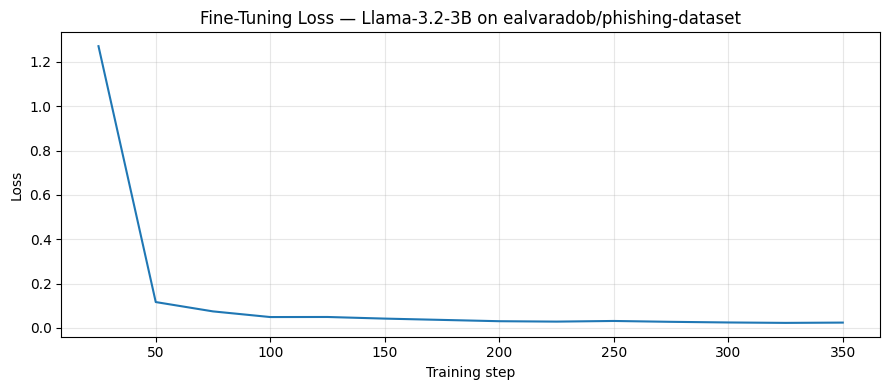

Saved as training_loss.png


In [18]:
loss_history = trainer.state.log_history
losses = [(h["step"], h["loss"]) for h in loss_history if "loss" in h]
if losses:
    steps, vals = zip(*losses)
    plt.figure(figsize=(9, 4))
    plt.plot(steps, vals, linewidth=1.5)
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Fine-Tuning Loss — Llama-3.2-3B on ealvaradob/phishing-dataset")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_loss.png", dpi=150)
    plt.show()
    print("Saved as training_loss.png")

## 10. Evaluation After Fine-Tuning

In [19]:
print("=" * 60)
print("After fine-tuning on ealvaradob/phishing-dataset")
print("=" * 60)

ft_metrics, ft_results = evaluate_on_set(eval_data, name="fine-tuned (Nazario+Enron)")

After fine-tuning on ealvaradob/phishing-dataset


Evaluating (fine-tuned (Nazario+Enron)):   0%|          | 0/300 [00:00<?, ?it/s]


fine-tuned (Nazario+Enron) metrics:
  accuracy  : 0.9433
  precision : 0.9854
  recall    : 0.9000
  f1        : 0.9408
  fpr       : 0.0133
  tn        : 148
  fp        : 2
  fn        : 15
  tp        : 135


## 11. Compare Baseline vs. Fine Tuned

In [20]:
rows = []
for metric in ["accuracy", "precision", "recall", "f1", "fpr"]:
    base_v = baseline_metrics[metric]
    ft_v   = ft_metrics[metric]
    delta  = ft_v - base_v
    rows.append({
        "Metric":            metric.upper() + (" (lower=better)" if metric == "fpr" else ""),
        "Baseline":          f"{base_v:.4f}",
        "Fine-tuned":        f"{ft_v:.4f}",
        "Δ":                 f"{delta:+.4f}",
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))
df_compare.to_csv("phishing_before_after.csv", index=False)
print("\nSaved as phishing_before_after.csv")

            Metric Baseline Fine-tuned       Δ
          ACCURACY   0.5267     0.9433 +0.4167
         PRECISION   0.5138     0.9854 +0.4716
            RECALL   0.9933     0.9000 -0.0933
                F1   0.6773     0.9408 +0.2635
FPR (lower=better)   0.9400     0.0133 -0.9267

Saved as phishing_before_after.csv


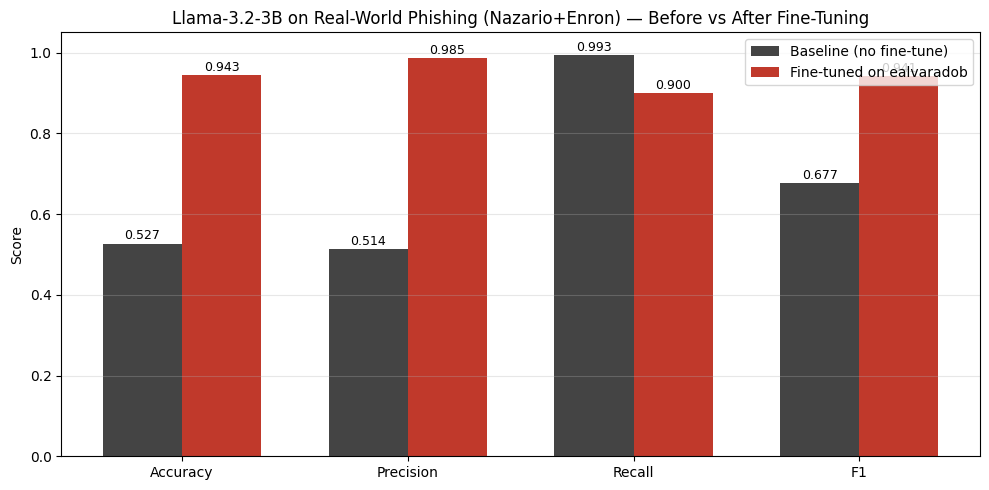

In [21]:
metric_names = ["Accuracy", "Precision", "Recall", "F1"]
base_vals = [baseline_metrics[m.lower()] for m in metric_names]
ft_vals   = [ft_metrics[m.lower()]       for m in metric_names]

x = np.arange(len(metric_names)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, base_vals, width, label="Baseline (no fine-tune)", color="#444")
b2 = ax.bar(x + width/2, ft_vals,   width, label="Fine-tuned on ealvaradob", color="#c0392b")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Llama-3.2-3B on Real-World Phishing (Nazario+Enron) — Before vs After Fine-Tuning")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("before_after_comparison.png", dpi=150)
plt.show()

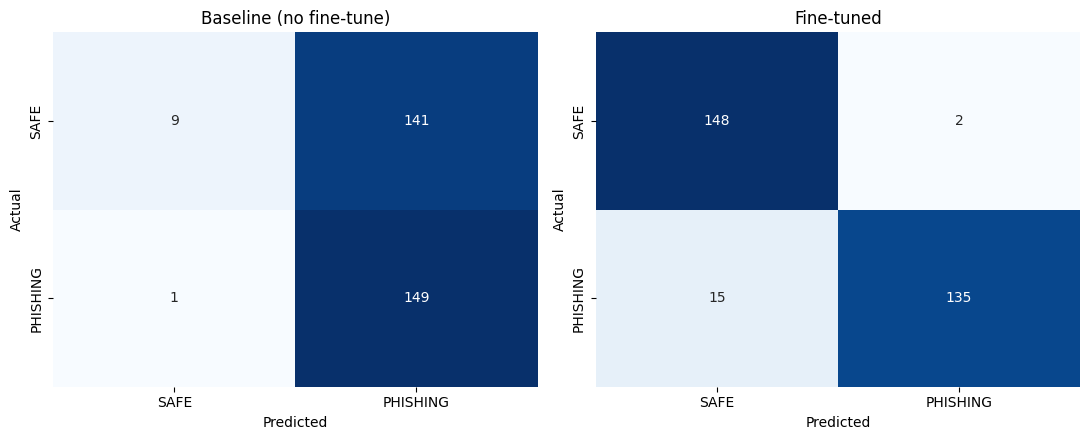

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

def plot_cm(ax, metrics, title):
    cm = np.array([[metrics["tn"], metrics["fp"]],
                   [metrics["fn"], metrics["tp"]]])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["SAFE", "PHISHING"],
                yticklabels=["SAFE", "PHISHING"], cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)

plot_cm(axes[0], baseline_metrics, "Baseline (no fine-tune)")
plot_cm(axes[1], ft_metrics,       "Fine-tuned")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

## 12. Qualitative Comparison

In [23]:
# where baseline FAILED but fine-tuned SUCCEEDED
flipped_cases = []
for i, (b, f) in enumerate(zip(baseline_results, ft_results)):
    if not b["is_correct"] and f["is_correct"]:
        flipped_cases.append({
            "index": i,
            "label":     b["label_str"],
            "email":     b["email_excerpt"],
            "source":    b["source"],
            "baseline":  b["raw_output"][:250],
            "finetuned": f["raw_output"][:250],
        })

print(f"Cases where fine-tuning corrected the baseline: {len(flipped_cases)}\n")
for c in flipped_cases[:5]:
    print(f"=== Truth: {c['label']}, Source: {c['source']} ===")
    print(f"Email: {c['email']}...")
    print(f"\nBASELINE:  {c['baseline']}")
    print(f"\nFINE-TUNED: {c['finetuned']}")
    print("\n" + "-"*70 + "\n")

Cases where fine-tuning corrected the baseline: 140

=== Truth: SAFE, Source: enron ===
Email: Subject: re : wednesday

re : wednesday vince , thanks for letting me know . i will see you on wednesday .
regards ,
giu...

BASELINE:  Analysis: The email contains a suspicious URL (http://www.gappy.org) and a potential impersonation of a sender (Vince J. Kaminski) with a similar email address (vince.j.kaminski@enron.com), which could be a phishing attempt.
Verdict: PHISHING

FINE-TUNED: Analysis: The email reads as a normal communication, with no obvious phishing indicators such as urgency, brand impersonation, or credential requests.

Verdict: SAFE

----------------------------------------------------------------------

=== Truth: SAFE, Source: enron ===
Email: Subject: asking for advice regarding summer associate position at enron

asking for advice regarding summer associate po...

BASELINE:  Analysis: The email contains a suspicious URL (producer application) and an impersonation of a l

In [24]:
pd.DataFrame(baseline_results).to_csv("baseline_per_sample.csv", index=False)
pd.DataFrame(ft_results).to_csv("finetuned_per_sample.csv", index=False)
print("Saved baseline_per_sample.csv and finetuned_per_sample.csv")

Saved baseline_per_sample.csv and finetuned_per_sample.csv


## 13. Save the Fine-Tuned Adapter

In [25]:
model.save_pretrained("llama-3.2-3b-spearphishing-lora")
tokenizer.save_pretrained("llama-3.2-3b-spearphishing-lora")
print("Saved LoRA adapter to ./llama-3.2-3b-spearphishing-lora/")

Unsloth: Restored added_tokens_decoder metadata in llama-3.2-3b-spearphishing-lora/tokenizer_config.json.


Saved LoRA adapter to ./llama-3.2-3b-spearphishing-lora/


In [26]:
# Export fine-tuned model to GGUF
print("Exporting fine-tuned model to GGUF... (10-15 minutes)")
model.save_pretrained_gguf(
    "llama-3.2-3b-spearphishing-gguf",
    tokenizer,
    quantization_method="q4_k_m",
)
print("✓ Exported to ./llama-3.2-3b-spearphishing-gguf/")

Exporting fine-tuned model to GGUF... (10-15 minutes)
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in llama-3.2-3b-spearphishing-gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [03:53<00:00, 116.67s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [03:16<00:00, 98.26s/it]


Unsloth: Merge process complete. Saved to `/content/llama-3.2-3b-spearphishing-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['llama-3.2-3b-spearphishing-gguf_gguf/llama-3.2-3b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
SYSTEM_MSG = "You are a cybersecurity analyst specialized in detecting phishing attacks."

modelfile_baseline = f'''FROM llama3.2:3b-instruct
SYSTEM """{SYSTEM_MSG}"""
PARAMETER temperature 0.1
PARAMETER num_ctx 4096
'''

modelfile_finetuned = f'''FROM ./llama-3.2-3b-spearphishing-gguf/unsloth.Q4_K_M.gguf
SYSTEM """{SYSTEM_MSG}"""
PARAMETER temperature 0.1
PARAMETER num_ctx 4096
'''

with open("Modelfile.baseline", "w") as f:
    f.write(modelfile_baseline)
with open("Modelfile.finetuned", "w") as f:
    f.write(modelfile_finetuned)

print("✓ Created Modelfile.baseline and Modelfile.finetuned")
print("\nDownload these files + llama-3.2-3b-spearphishing-gguf/ folder to your machine.")

✓ Created Modelfile.baseline and Modelfile.finetuned

Download these files + llama-3.2-3b-spearphishing-gguf/ folder to your machine.


In [28]:
print("="*70)
print("LOCAL OLLAMA SETUP (run on your local machine)")
print("="*70)
print("\n# Import baseline:")
print("  cd /path/to/Modelfile.baseline")
print("  ollama create phishing-baseline -f Modelfile.baseline\n")
print("# Import fine-tuned:")
print("  cd /path/to/llama-3.2-3b-spearphishing-gguf/")
print("  ollama create phishing-finetuned -f ../Modelfile.finetuned\n")
print("# Verify:")
print("  ollama list\n")
print("# Then run phishing_ollama_agent.ipynb")
print("="*70)

LOCAL OLLAMA SETUP (run on your local machine)

# Import baseline:
  cd /path/to/Modelfile.baseline
  ollama create phishing-baseline -f Modelfile.baseline

# Import fine-tuned:
  cd /path/to/llama-3.2-3b-spearphishing-gguf/
  ollama create phishing-finetuned -f ../Modelfile.finetuned

# Verify:
  ollama list

# Then run phishing_ollama_agent.ipynb
